# Interplay: what do the pairing heads write? — counterfactual interchange intervention

Question: do the pairing heads carry the **bound output content** forward into the demo
output positions, or only a **structural/positional** marker?

Design (inspired by Gur-Arieh & Geva, "Mixing Mechanisms"):
- **original** prompt: correctly paired demos (`inp -> out`), correct query.
- **counterfactual** prompt: same query & inputs, but demo outputs are DERANGED
  (each input bound to a *different* demo's output).
- Patch ONLY the pairing heads' output (their `z @ W_O` contribution) at the demo
  **output positions**, from counterfactual into original, layer by layer.
- Read the query's generated answer:
    - if it flips toward the **counterfactual (mis-paired) output** -> pairing heads
      carry bound-output *content*.
    - if it stays the **original correct output** -> pairing heads carry only structure.

Run on **nonce/arith** (output only available from demos; no parametric-prior confound).
Reuses repo machinery. Put in `experiments/interplay/`.

In [1]:
import os, sys, pickle
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch
from collections import defaultdict
from tqdm.auto import tqdm

import experiments.pairing._common as C
from data.loaders import load_dataset
from data.prompts import build_icl_prompt
from utils.heads import get_head_sets_multiscope, select_scope
from utils.positions import find_per_demo_positions_robust
from utils.eval import check_correct_multitoken
sns.set_context('notebook')

## Config

In [2]:
DATASET   = 'nonce+arithmetic'
HEAD_PCT  = 10
SCOPE     = 'pooled'
N_PROMPTS = 15           # prompts per task
HEAD_SET  = 'pairing'    # which heads to interchange ('pairing' or 'aggregation' as control)
CUDA      = '0'
SEED      = 0
ds_tag = DATASET.replace('+','_')

model = C.load_model(cuda_visible=CUDA)
n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
splits = load_dataset(DATASET)
tasks = sorted(splits.keys())
print(f'{DATASET}: {len(tasks)} tasks')

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
nonce+arithmetic: 20 tasks


## Head set

In [3]:
cache = f'../../results/head_sets_{ds_tag}_pct{HEAD_PCT}.pkl'
with open(cache,'rb') as f: ms = pickle.load(f)
heads = select_scope(ms, SCOPE)[HEAD_SET]
rand_heads = select_scope(ms, SCOPE)[f'{HEAD_SET}_rand']
print(f'{len(heads)} {HEAD_SET} heads')

67 pairing heads


## Build counterfactual (deranged-pairing) version of each prompt
Same inputs, same query; demo OUTPUTS deranged so each input is bound to a different
demo's output. The query's correct answer is unchanged (it's computed from the query
input), but the *demonstrated* binding now points elsewhere.

In [9]:
import random
def derange(xs, rng):
    n=len(xs); idx=list(range(n))
    for _ in range(100):
        rng.shuffle(idx)
        if all(idx[i]!=i for i in range(n)): return [xs[i] for i in idx]
    return [xs[(i+1)%n] for i in range(n)]

def make_pair(pd_, rng):
    demos = pd_['demo_pairs']; qi = pd_['query_input']
    ins  = [a for a,_ in demos]; outs=[b for _,b in demos]
    cf_ins = derange(ins, rng)               # <-- derange INPUTS now
    cf_demos = list(zip(cf_ins, outs))       # outputs stay in place
    return (build_icl_prompt(demos, qi), demos,
            build_icl_prompt(cf_demos, qi), cf_demos, pd_['query_output'])

## Interchange: patch pairing-head OUTPUT at demo output positions (orig <- counterfactual)
For each layer L, we cache the counterfactual's `hook_z` at L, and during the original
run we overwrite ONLY the selected heads' z at the demo output positions with the
counterfactual's z. Then greedy-decode the query answer.

We record, per (prompt, layer): does the generation match the ORIGINAL correct answer,
or the COUNTERFACTUAL (mis-paired) answer the query input maps to under the deranged demos?

In [10]:
def out_positions(prompt, demos):
    pd = find_per_demo_positions_robust(model, prompt, demos)
    return [p for d in pd for p in d.get('output_positions', [])] if False else            [p for d in pd for p in d.get('output_positions', [])]

@torch.no_grad()
def cf_z_at_layer(cf_prompt, L):
    toks = model.to_tokens(cf_prompt, prepend_bos=True)
    _, cache = model.run_with_cache(toks, names_filter=lambda n: n==f'blocks.{L}.attn.hook_z')
    z = cache[f'blocks.{L}.attn.hook_z'][0].clone()   # (seq, n_heads, d_head)
    del cache; torch.cuda.empty_cache(); return z

@torch.no_grad()
def patched_generate(orig_prompt, orig_demos, cf_prompt, L, head_list, max_new=12):
    # positions to patch = demo output positions in the ORIGINAL prompt
    pos = out_positions(orig_prompt, orig_demos)
    cf_z = cf_z_at_layer(cf_prompt, L)              # counterfactual z at layer L
    by_head = defaultdict(list)
    for (l,h) in head_list:
        if l==L: by_head[l].append(h)
    hh = by_head.get(L, [])
    if not hh:   # no selected head at this layer -> patching does nothing
        return None
    def hook(z, hook):
        for h in hh:
            for p in pos:
                if p < z.shape[1] and p < cf_z.shape[0]:
                    z[0, p, h, :] = cf_z[p, h, :]
        return z
    toks = model.to_tokens(orig_prompt, prepend_bos=True)
    gen=[]
    cur=toks.clone()
    for _ in range(max_new):
        logits = model.run_with_hooks(cur, fwd_hooks=[(f'blocks.{L}.attn.hook_z', hook)])[0,-1]
        nt=logits.argmax().item(); gen.append(nt)
        cur=torch.cat([cur, torch.tensor([[nt]],device=cur.device)],1)
    return model.tokenizer.decode(gen).strip()

def matches(decoded, target):
    t=str(target).strip()
    return decoded[:len(t)]==t if decoded else False

## Run the sweep
For each prompt and each layer that contains a selected head, patch and classify the
answer as: follows-original / follows-counterfactual / other.

In [11]:
# ---- fast interchange sweep: precompute cf z once per prompt, early-exit generation ----
import random
from collections import defaultdict

def out_positions(prompt, demos):
    pdz = find_per_demo_positions_robust(model, prompt, demos)
    return [p for d in pdz for p in d.get('output_positions', [])]

@torch.no_grad()
def all_cf_z(cf_prompt):
    toks = model.to_tokens(cf_prompt, prepend_bos=True)
    _, cache = model.run_with_cache(toks, names_filter=lambda n: 'attn.hook_z' in n)
    z = {L: cache[f'blocks.{L}.attn.hook_z'][0].clone() for L in range(n_layers)}
    del cache; torch.cuda.empty_cache(); return z

@torch.no_grad()
def patched_eval(orig_prompt, pos, cf_zL, hh, L, ans, max_new=12):
    # patch selected heads hh at output positions `pos` with counterfactual z at layer L,
    # greedy-decode with early exit; return (decoded, follows_orig 0/1)
    target = str(ans).strip()
    def hook(z, hook):
        for h in hh:
            for p in pos:
                if p < z.shape[1] and p < cf_zL.shape[0]:
                    z[0, p, h, :] = cf_zL[p, h, :]
        return z
    cur = model.to_tokens(orig_prompt, prepend_bos=True)
    gen = []
    for _ in range(max_new):
        logits = model.run_with_hooks(cur, fwd_hooks=[(f'blocks.{L}.attn.hook_z', hook)])[0, -1]
        nt = logits.argmax().item(); gen.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], 1)
        dec = model.tokenizer.decode(gen).strip()
        if dec == target:                          return dec, 1
        if len(dec) >= len(target):                return dec, 0
        if dec and not target.startswith(dec):     return dec, 0
    return model.tokenizer.decode(gen).strip(), 0

# heads grouped by layer
heads_by_layer = defaultdict(list)
for (l, h) in heads:
    heads_by_layer[l].append(h)
layers_with_heads = sorted(heads_by_layer.keys())

rng = random.Random(SEED)
rows = []
jobs = [(t,i,pd_) for t in tasks for i,pd_ in enumerate(splits[t]['icl_prompts'][:N_PROMPTS])]
for t, i, pd_ in tqdm(jobs):
    op, od, cfp, cfd, ans = make_pair(pd_, rng)
    pos = out_positions(op, od)
    if not pos:
        continue
    cf_z = all_cf_z(cfp)                       # one forward pass for ALL layers
    for L in layers_with_heads:
        dec, follows = patched_eval(op, pos, cf_z[L], heads_by_layer[L], L, ans)
        rows.append({'task': t, 'prompt_idx': i, 'layer': L,
                     'decoded': dec, 'orig_ans': ans, 'follows_orig': follows})
    del cf_z; torch.cuda.empty_cache()

df = pd.DataFrame(rows)
print(df.shape)
df.head()

  0%|          | 0/300 [00:00<?, ?it/s]

(4200, 6)


,task,prompt_idx,layer,decoded,orig_ans,follows_orig
0,add_13,0,0,57,57,1
1,add_13,0,1,57,57,1
2,add_13,0,3,57,57,1
3,add_13,0,4,57,57,1
4,add_13,0,5,59,57,0


## Result: does patching pairing-head outputs (from deranged demos) break the answer?
If pairing heads carry **content**, patching the deranged binding should REDUCE
follows_orig (the answer breaks). If they carry only **structure**, follows_orig stays high.
We compare against a baseline: the un-patched original accuracy.

unpatched original accuracy: 0.997


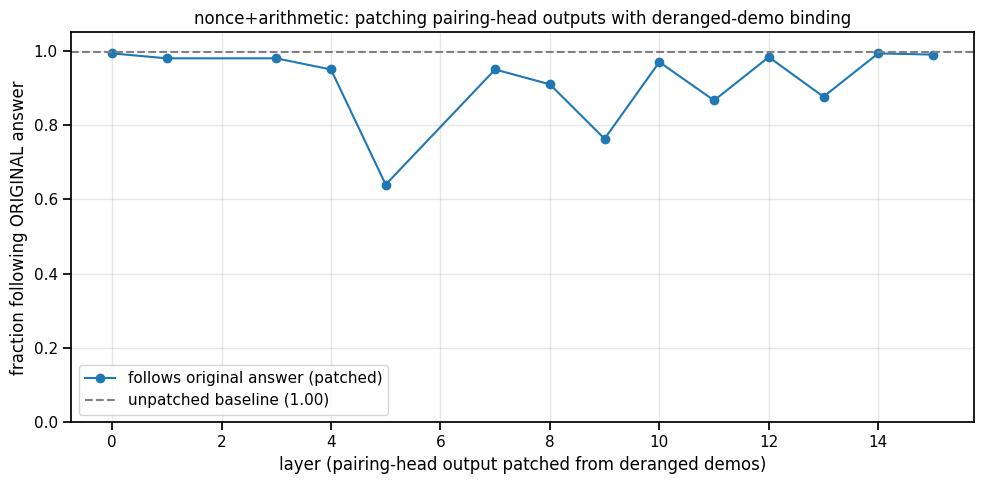

layer
0     0.993
1     0.980
3     0.980
4     0.950
5     0.640
7     0.950
8     0.910
9     0.763
10    0.970
11    0.867
12    0.983
13    0.877
14    0.993
15    0.990


In [12]:
# baseline: unpatched original accuracy on these prompts
base_rows=[]
for t,i,pd_ in jobs:
    tok=model.to_tokens(pd_['prompt'],prepend_bos=True)
    base_rows.append({'task':t,'ok':check_correct_multitoken(model,tok,pd_['query_output'])})
base = pd.DataFrame(base_rows)['ok'].mean()
print(f'unpatched original accuracy: {base:.3f}')

per_layer = df.groupby('layer')['follows_orig'].mean()
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(per_layer.index, per_layer.values, 'o-', label='follows original answer (patched)')
ax.axhline(base, ls='--', color='gray', label=f'unpatched baseline ({base:.2f})')
ax.set(xlabel='layer (pairing-head output patched from deranged demos)',
       ylabel='fraction following ORIGINAL answer', ylim=(0,1.05),
       title=f'{DATASET}: patching {HEAD_SET}-head outputs with deranged-demo binding')
ax.legend(); ax.grid(True,alpha=.3)
fig.tight_layout(); fig.savefig(f'interchange_{ds_tag}_{HEAD_SET}.png',dpi=130,bbox_inches='tight'); plt.show()
print(per_layer.round(3).to_string())

## Interpretation
- **follows_orig drops well below baseline at some layers** -> patching the pairing
  heads' output (carrying the *deranged* binding) corrupts the answer: pairing heads
  carry **content** that propagates to the query. The layers where it drops = where
  that content is written/used.
- **follows_orig stays at baseline** -> the pairing heads' output at demo positions
  doesn't carry answer-determining content (structural / positional only).

Controls to run next (flip config + re-run):
- `HEAD_SET='aggregation'` — should it matter less at output positions? (aggregation
  acts at the final position, so patching its output-position z may do little).
- patch `rand_heads` instead of `heads` — random-head control; effect should be smaller.